In [1]:
import geopandas as gpd
import pandas as pd
from blocksnet.config import log_config

log_config.set_logger_level('WARNING')

/home/mvin/Urbanomy/.venv/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


# Оценка стоимости земли проекта

In [2]:
scenario_blocks = pd.read_pickle('../data/scenario_blocks.pickle')
scenario_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862
4,"POLYGON ((388001.306 6643195.969, 388000.75 66...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN


In [3]:
blocks = pd.read_pickle('../data/prepared_blocks.pickle')
blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.321243,...,202399.732193,0.062008,0.030930,0.000000,2.004756,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.767788,...,201529.493481,0.202340,0.090030,0.000000,2.247469,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.641911,...,164663.859830,0.151737,0.091165,0.000000,1.664419,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.055572,...,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316006,...,16.489152,0.079224,0.019164,0.000000,4.133916,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


In [4]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('../data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=blocks,
)
blocks_pred = estimator.predict()



In [5]:
blocks_pred.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id,y_log_pred,price_pred
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180,6260.321243,...,0.030930,0.000000,2.004756,low-rise non-residential,127.337432,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0,18.194987,7.979628e+07
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081,18143.767788,...,0.090030,0.000000,2.247469,low-rise non-residential,125.993903,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1,18.789743,1.446378e+08
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381,15011.641911,...,0.091165,0.000000,1.664419,low-rise non-residential,123.419051,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2,18.161945,7.720270e+07
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862,22467.055572,...,0.139053,0.404539,3.230005,low-rise model,122.524407,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3,19.368322,2.579618e+08
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316006,...,0.019164,0.000000,4.133916,mid-rise non-residential,122.658674,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4,10.300267,2.974055e+04


# Визуализация стоимости земли

Суммарная стоимость:
 • Сценические кварталы: 3 991 449 041 ₽
 • Контекст: 145 771 433 743 ₽
 • Все кварталы: 149 762 882 784 ₽


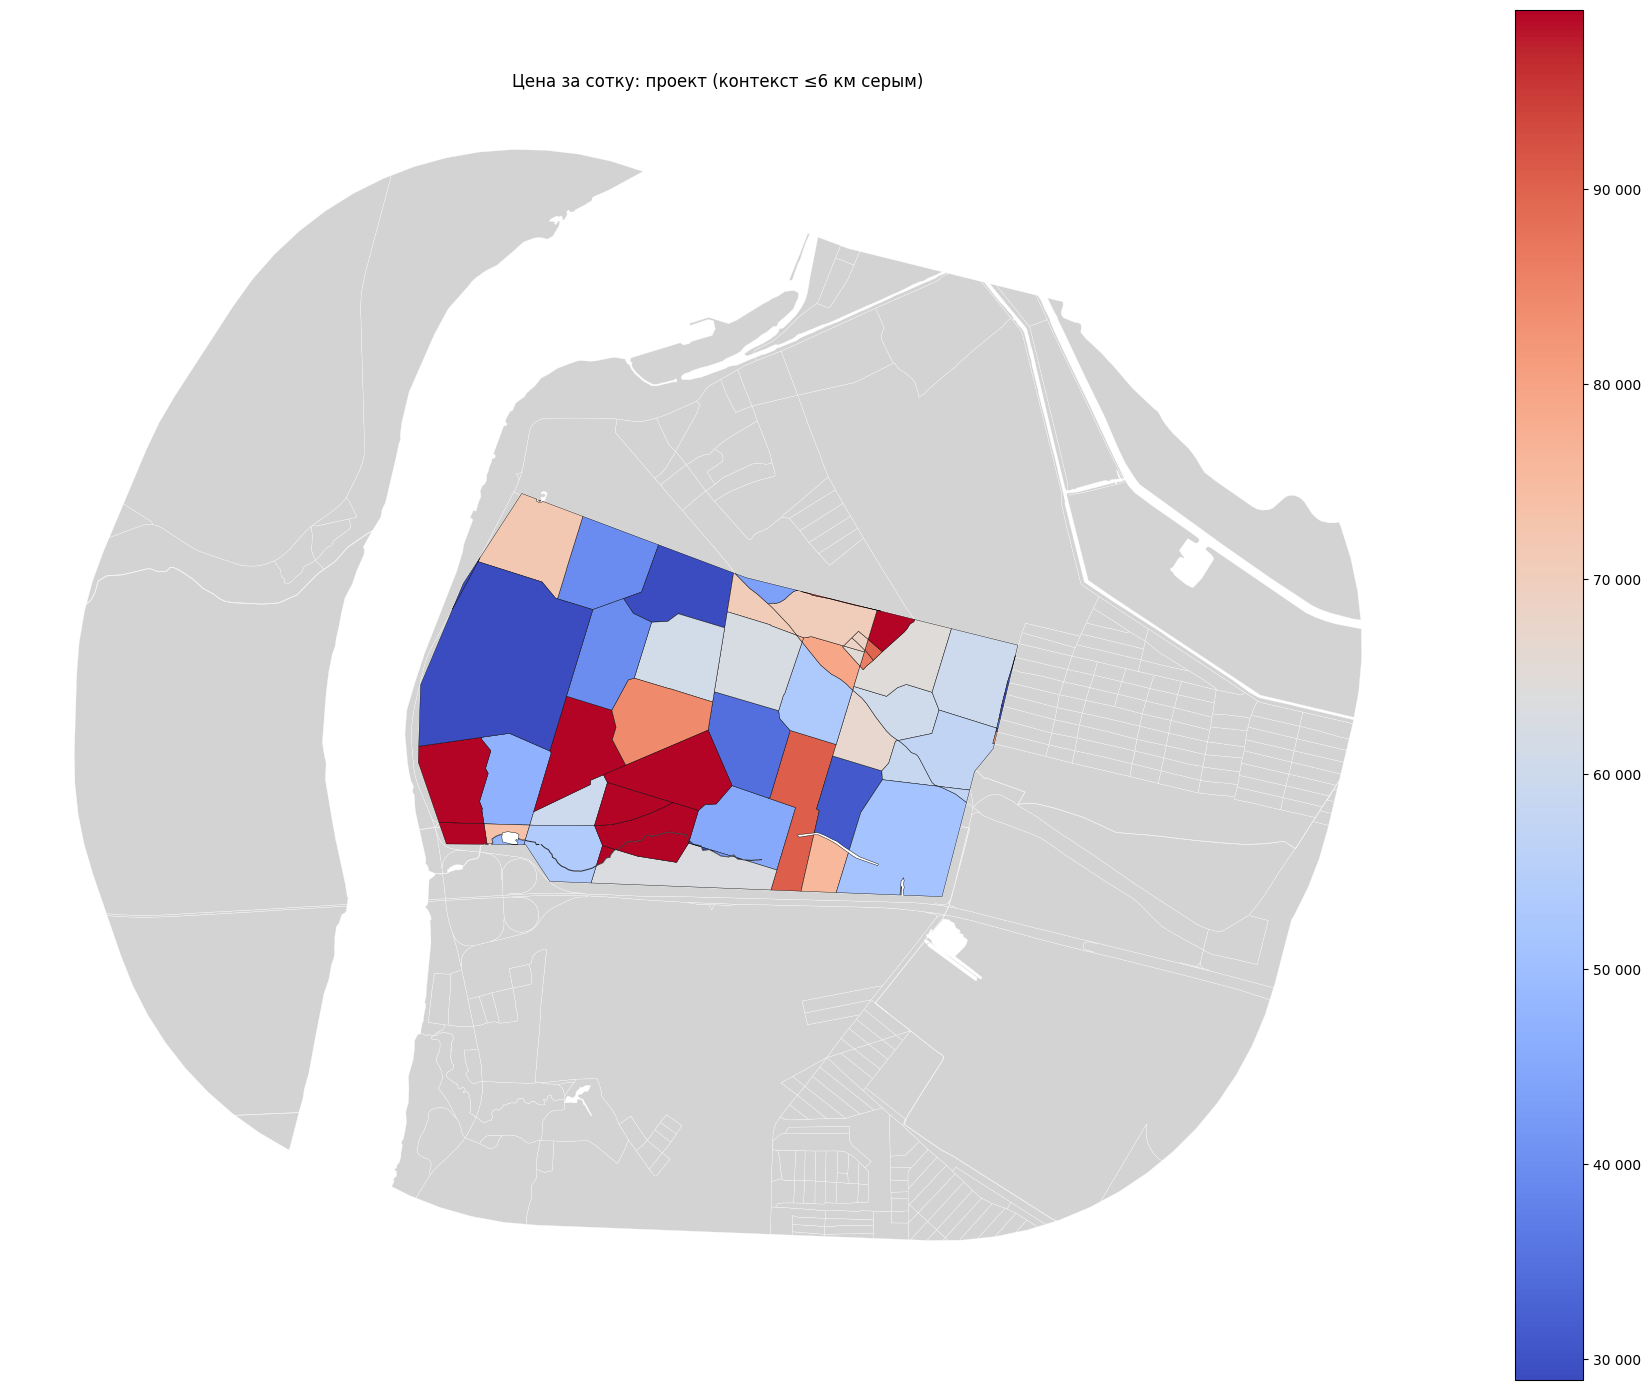

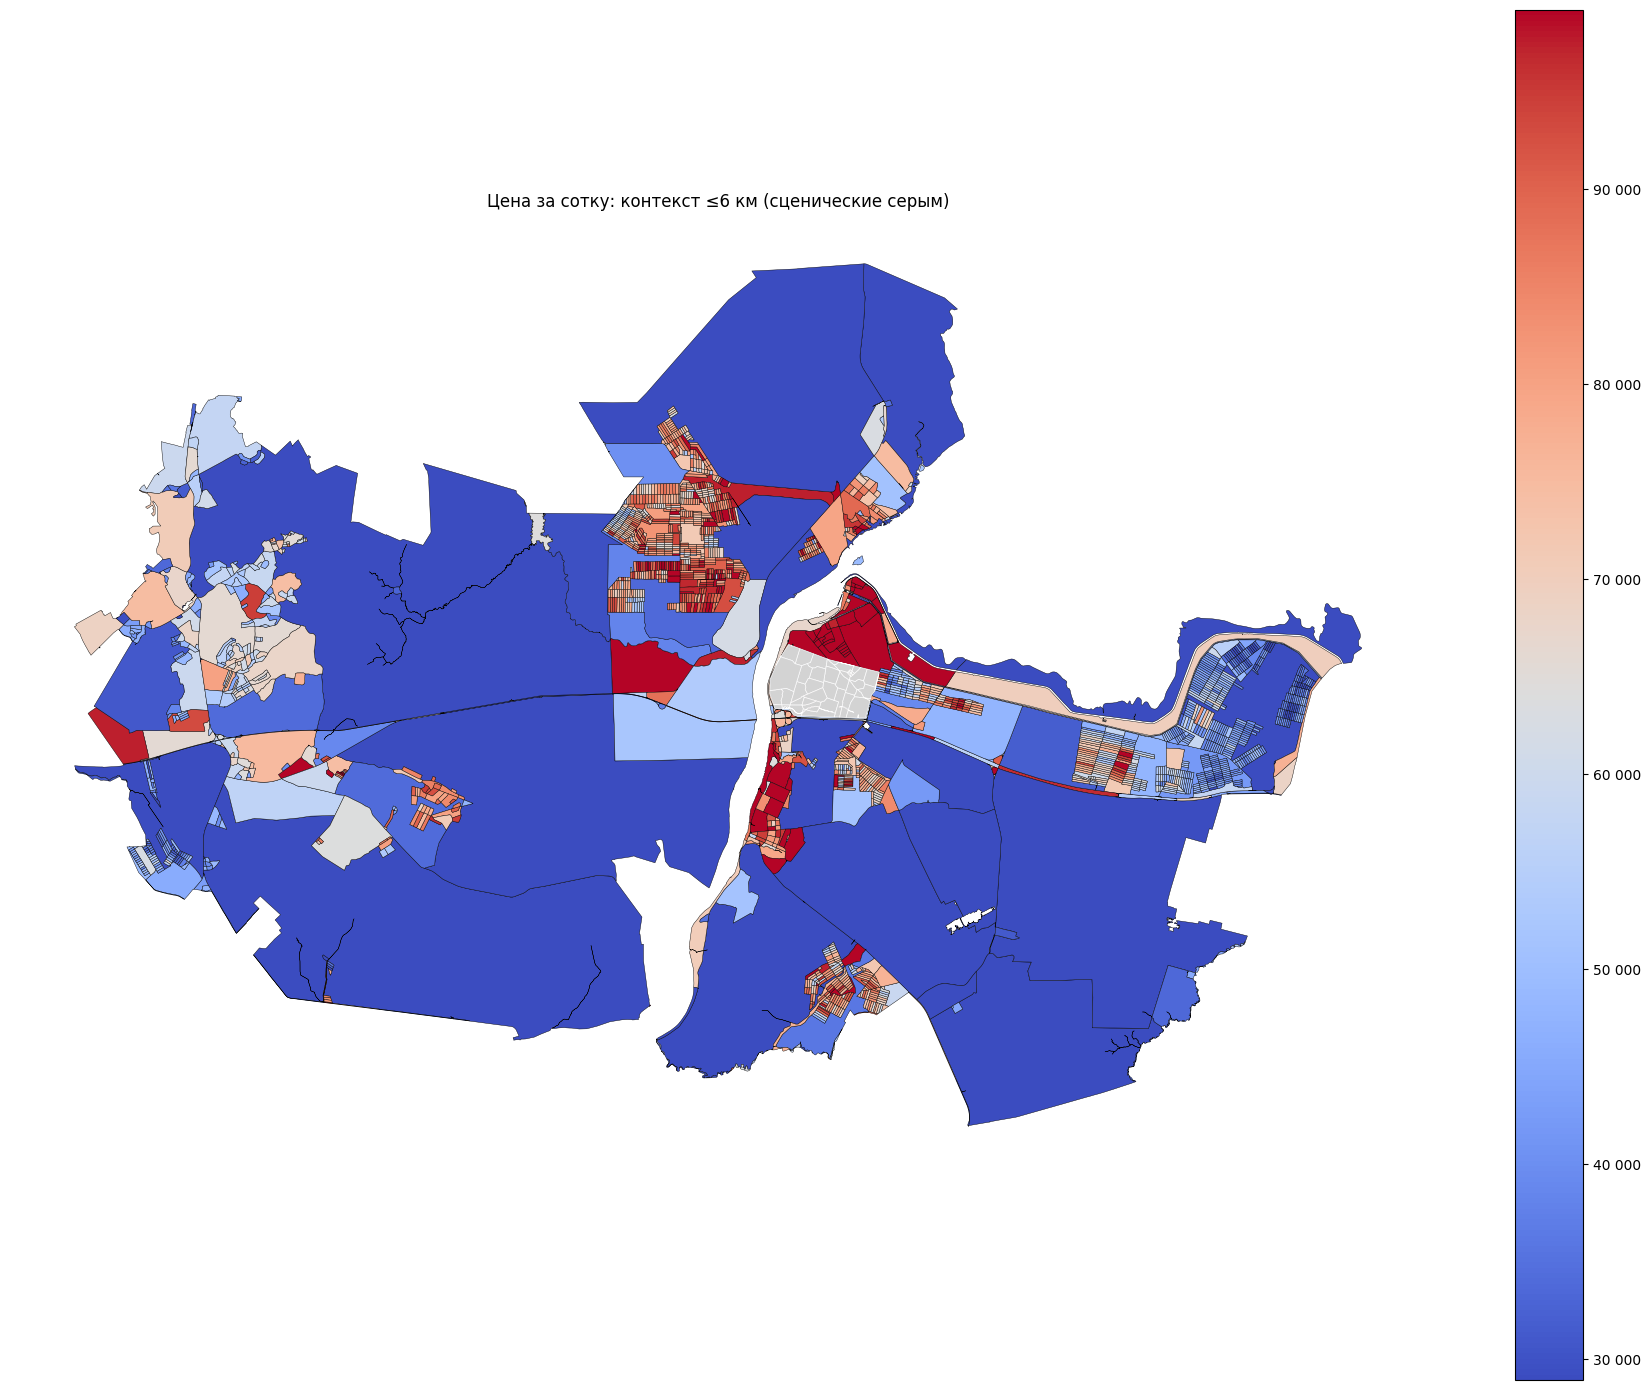

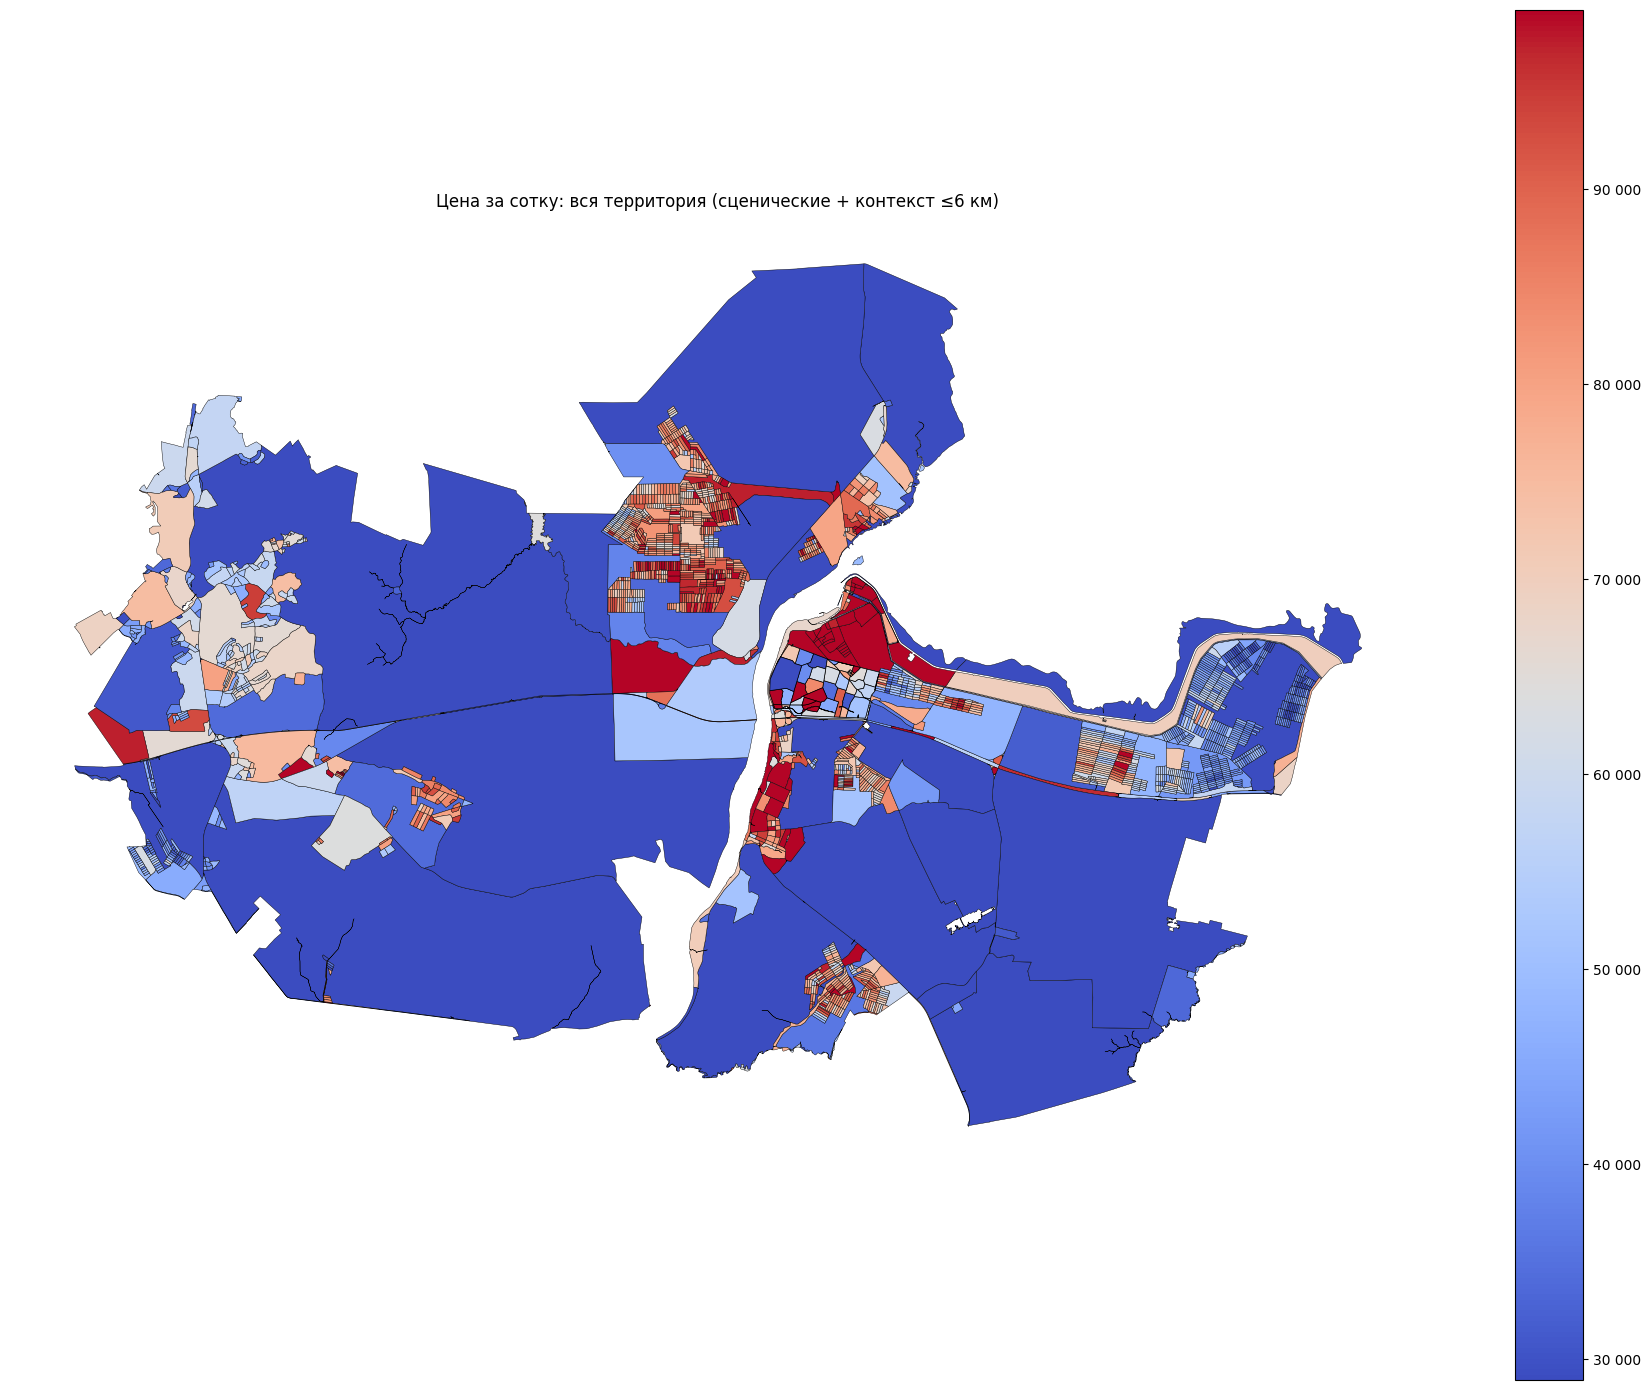

In [6]:
from urbanomy.methods.land_value_modeling import plot_land_price_maps

visualization_output = plot_land_price_maps(
    blocks_pred=blocks_pred,
    scenario_blocks=scenario_blocks,
    buffer_radius_m=2000,
)



In [7]:
blocks_pred.to_pickle('../data/blocks_with_price.pickle')

# Сценарное изменение ТЭП участков

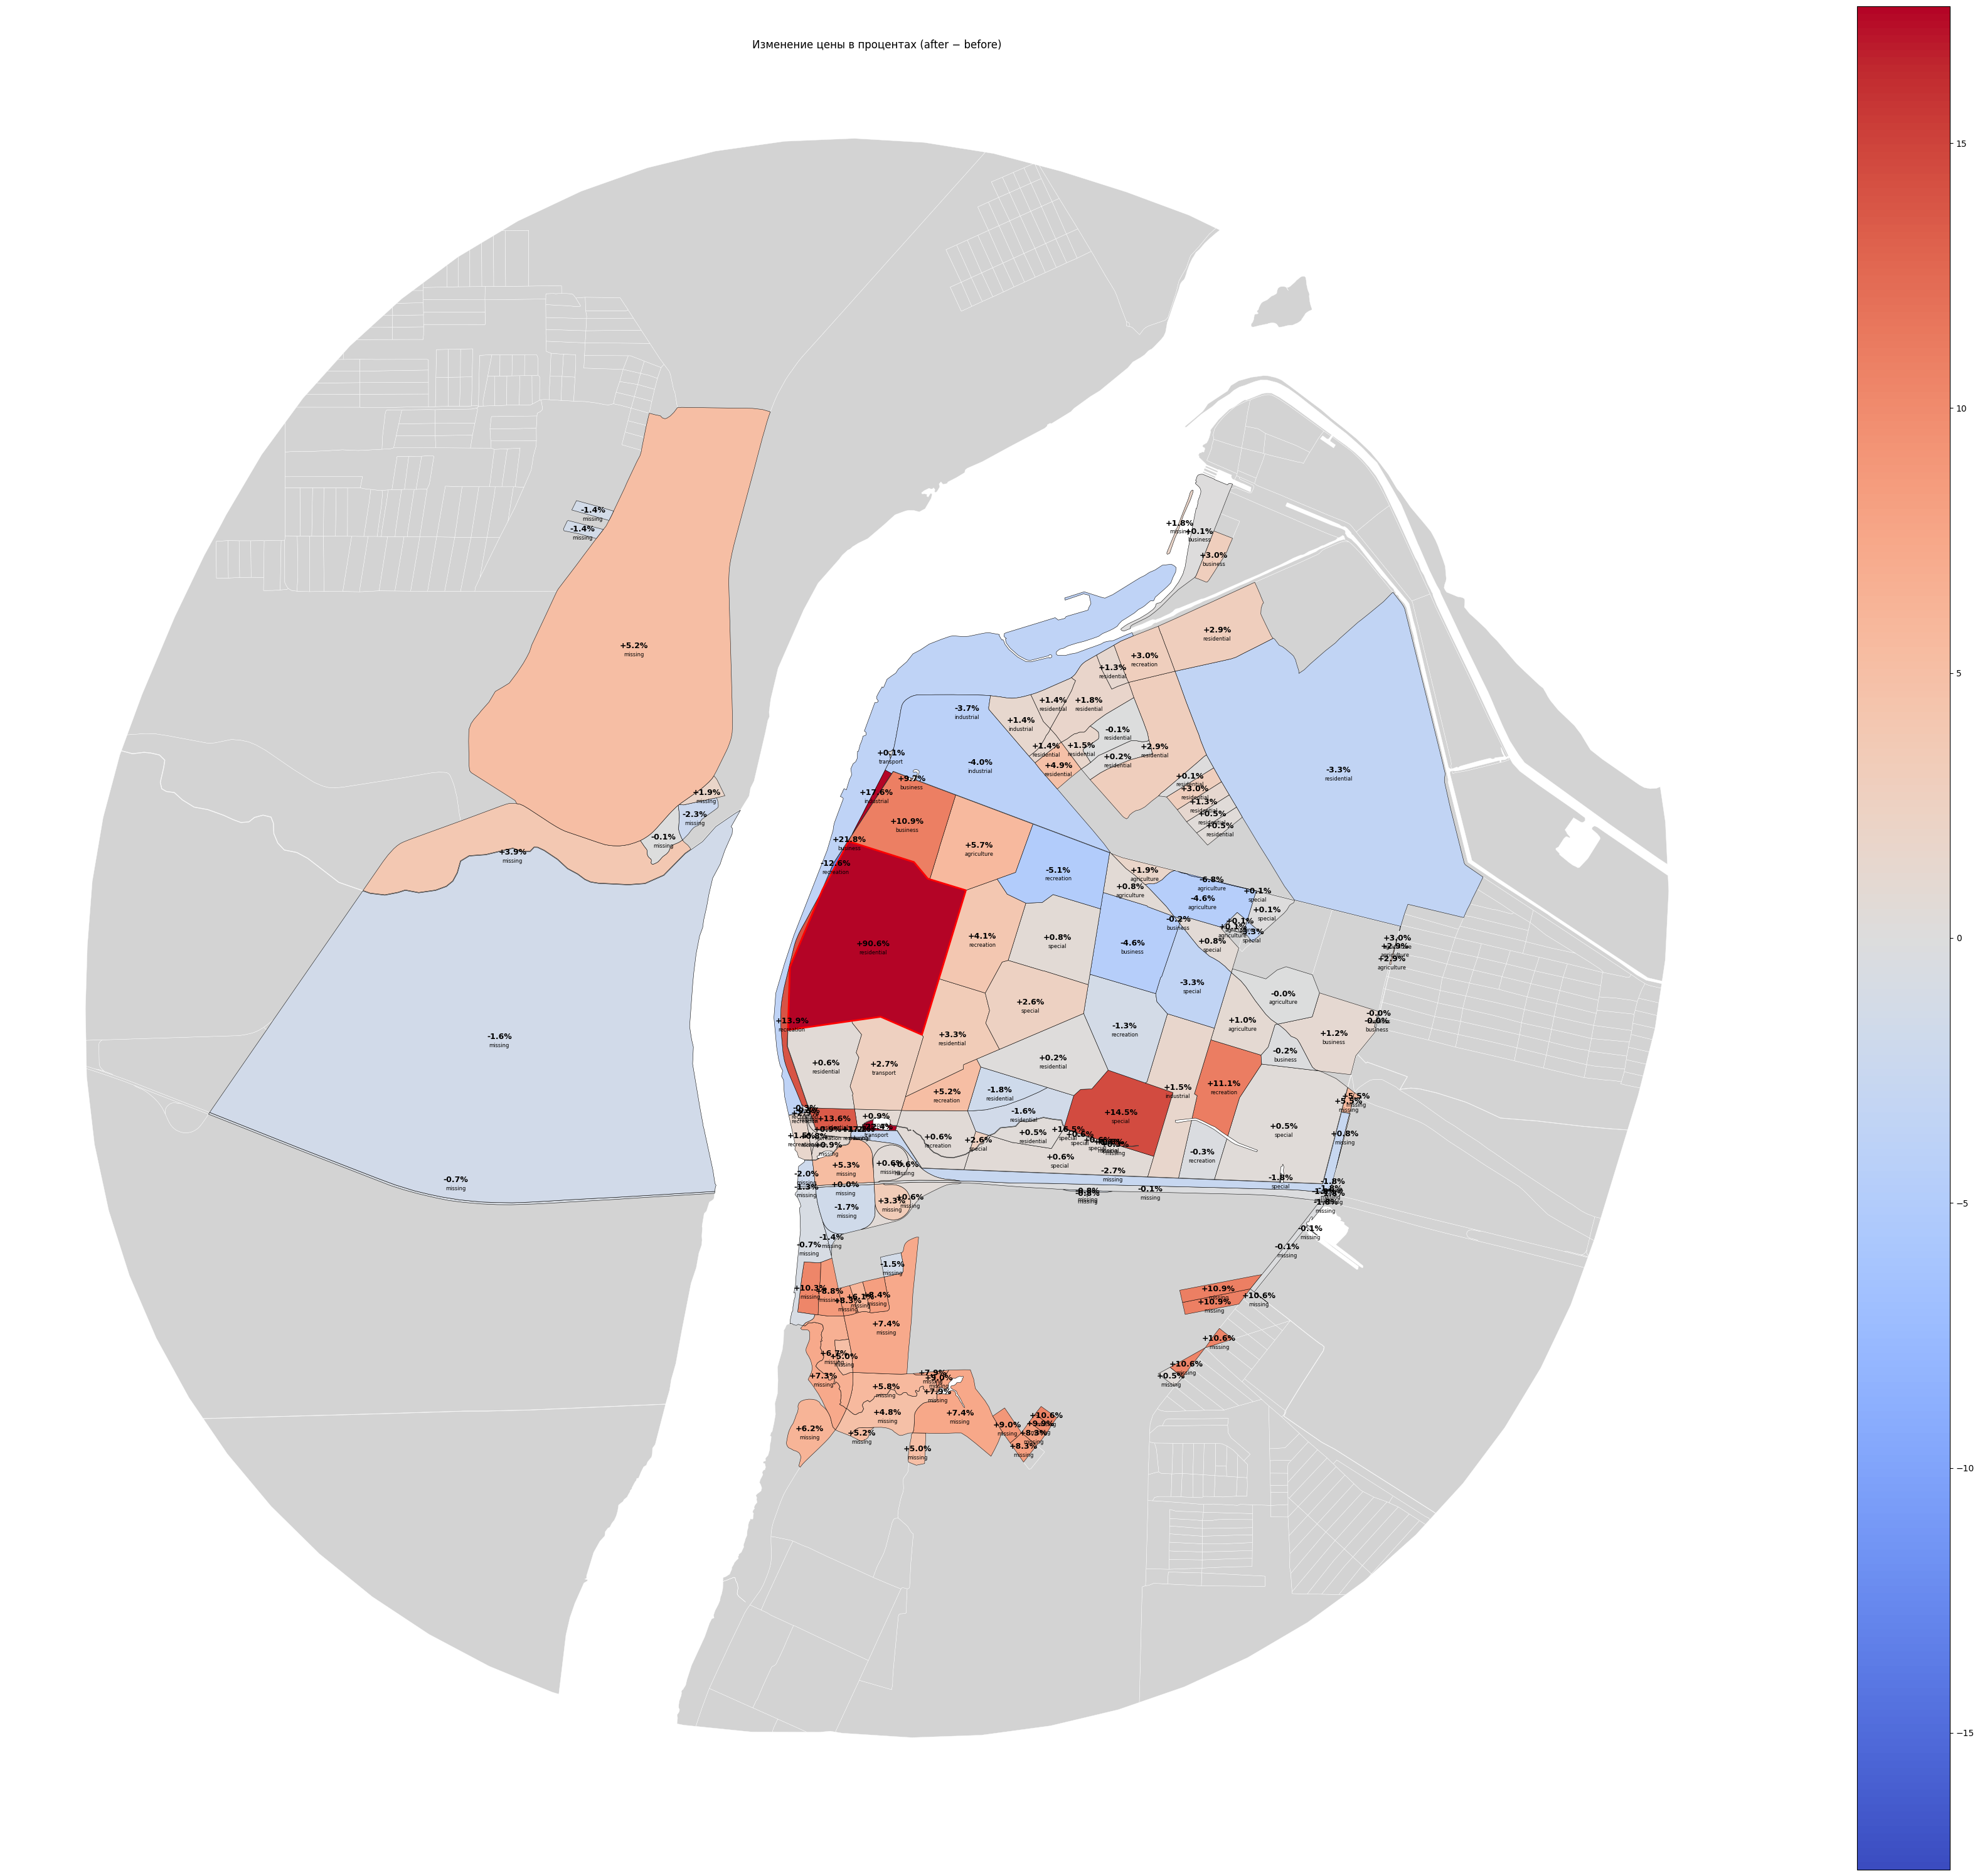


Статистика по кварталам в пределах буфера (|Δ₽| > 1e-09):
index | до (₽) → после (₽) | Δ₽ | Δ%
377 | 129 ₽ → 127 ₽ | -2 ₽ | -1.8%
387 | 65 021 ₽ → 63 869 ₽ | -1 152 ₽ | -1.8%
388 | 345 038 ₽ → 338 924 ₽ | -6 115 ₽ | -1.8%
1421 | 53 228 ₽ → 52 285 ₽ | -943 ₽ | -1.8%
1450 | 70 662 ₽ → 69 410 ₽ | -1 252 ₽ | -1.8%
1568 | 4 219 617 ₽ → 4 667 408 ₽ | +447 791 ₽ | +10.6%
669 | 4 196 650 ₽ → 4 639 987 ₽ | +443 337 ₽ | +10.6%
1535 | 21 592 657 ₽ → 23 957 023 ₽ | +2 364 366 ₽ | +10.9%
1524 | 49 152 ₽ → 54 345 ₽ | +5 193 ₽ | +10.6%
1536 | 30 336 067 ₽ → 33 657 824 ₽ | +3 321 757 ₽ | +10.9%
1525 | 13 789 220 ₽ → 13 769 363 ₽ | -19 857 ₽ | -0.1%
1559 | 6 334 154 ₽ → 6 363 905 ₽ | +29 751 ₽ | +0.5%
668 | 6 409 689 ₽ → 7 086 813 ₽ | +677 124 ₽ | +10.6%
614 | 222 089 ₽ → 220 208 ₽ | -1 881 ₽ | -0.8%
326 | 47 397 437 ₽ → 47 329 182 ₽ | -68 255 ₽ | -0.1%
378 | 671 074 ₽ → 665 391 ₽ | -5 684 ₽ | -0.8%
12 | 114 314 932 ₽ → 115 002 615 ₽ | +687 683 ₽ | +0.6%
325 | 92 567 742 ₽ → 90 053 992 ₽ | -2 513 750 

In [8]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks
changes = {
    'land_use': 'LandUse.RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
)

